# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head(5)
users.sample(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
2402,12402,Sofia,Lopez,33,Bogotá,2023-10-20 17:05:10.577644416,Basico,NaN
3962,13962,Sofia,Ramirez,60,?,2024-12-20 20:50:57.164291072,Basico,"1,72238E+18"
2080,12080,Carlos,Garcia,75,Cali,2023-07-24 13:01:02.115528888,Premium,NaN
1833,11833,Mateo,Torres,21,NaN,2023-05-17 21:49:17.239309832,Premium,NaN
3971,13971,Mateo,Garcia,60,MTY,2024-12-23 07:59:38.394598656,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print("Cantidad de valores nulos USERS")
print(users.isna().sum())
print("Proporción de valores nulos USERS")
print(users.isna().mean()*100)

Cantidad de valores nulos USERS
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos USERS
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [11]:
# cantidad de nulos para usage
print("Cantidad de valores nulos USAGE")
print(usage.isna().sum())
print("Porcentaje de valores nulos USAGE")
print(usage.isna().mean()*100)

Cantidad de valores nulos USAGE
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Porcentaje de valores nulos USAGE
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---
**Valores nulos**  
# ¿Qué columnas tienen valores faltantes y en qué proporción?
## RTA:
### 1️⃣ Tabla: `users`
#### 🔎 Diagnóstico
- `city` → ~11% de valores nulos.  
- `churn_date` → ~88% de valores nulos.
- 
### 2️⃣ Tabla: `usage`
#### 🔎 Diagnóstico
- `duration` → ~55% de valores nulos.  
- `length` → ~45% de valores nulos.  
- `date` → ~1% de valores nulos.
 
# Indica qué harías: ¿imputar, eliminar, ignorar?
## RTA:
### 1️⃣ Tabla: `users`
#### 📌 Análisis y recomendación

- **`city` (11%)**  
  Nivel de nulos moderado. Dado que la variable  es relevante para el objetivo del análisis, se recomienda **imputar la columna**   
  *(Alternativamente, podría imputarse como `"Sin ubicación"` para segmentación futura).*

- **`churn_date` (88%)**  
  Nivel crítico de valores faltantes (>80%). Además, no es relevante para el análisis actual.  
  👉 **Recomendación: eliminar la columna.**

### 2️⃣ Tabla: `usage`
#### 📌 Análisis y recomendación

- **`duration` (55%) y `length` (45%)**  
  Alto porcentaje de nulos. Se observa que estas variables dependen del tipo de uso (llamadas vs mensajes de texto).  
  👉 **Recomendación:** imputar de forma condicional según el tipo de evento:
  - Si es llamada → imputar `length` en 0 o nulo.
  - Si es mensaje → imputar `duration` en 0 o nulo.  
  *(Esto evita distorsionar métricas de uso).*

- **`date` (1%)**  
  Porcentaje bajo (<5%).  
  👉 **Recomendación:** imputación simple, por ejemplo con una fecha de referencia (`2024-01-01`) o eliminación puntual de esas filas si no afectan el volumen total.

---

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000



## Revisión de variables

### Columna `user_id`

- Se observa que los valores inician en **10.000** y terminan en **13999**.
- Corresponde a una variable únicamente de **identificación**.
- Contiene un total de **4000 registros**.

✍️ **Diagnóstico:**  
Es una variable llave (ID), no aporta valor analítico directo para el modelo o análisis descriptivo.

---

### Columna `age`

- Se identifica un valor mínimo de **-999**, lo cual no es coherente con la edad de una persona.
- La desviación estándar es **123**, un valor considerablemente alto.
- Esto sugiere la presencia de **valores atípicos extremos** que están distorsionando la distribución.

✍️ **Diagnóstico:**  
Existen valores inválidos y posiblemente registros erróneos que afectan la calidad del dato y las métricas descriptivas.

✅ **Acción recomendada:**  
1. Revisar los valores negativos o fuera de rango.
2. Reemplazar valores no coherentes (por ejemplo, edades < 0 o extremadamente altas).
3. Imputar con la **mediana**, ya que es más robusta frente a valores extremos.
4. Posteriormente analizar la distribución limpia para validar consistencia.


In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


## Revisión de variables – Tabla `usage`
### Columnas `id` y `user_id`
- La columna `id` corresponde a un **contador secuencial** de los registros de la tabla `usage`, iniciando en 1.
- Permite identificar cada actividad generada por X usuario.
- La columna `user_id` representa el **identificador del usuario** que realizó la actividad.
✍️ **Diagnóstico:**  
Ambas columnas cumplen una función de identificación (llaves), no aportan valor estadístico directo al análisis descriptivo.

---
### Columna `duration`
- Valor mínimo: **0**
- Valor máximo: **120**
- La desviación estándar es baja.
- El promedio y la mediana presentan valores coherentes.

✍️ **Diagnóstico:**  
Los valores son consistentes con el tipo de dato que representan y no se evidencian anomalías significativas. La baja dispersión indica que los datos están relativamente concentrados alrededor de la media.

✅ **Acción recomendada:**  
Mantener la variable sin modificaciones y considerar tanto la media como la mediana en el análisis descriptivo.

---
### Columna `length`

- Valor mínimo: **0**
- Valor máximo: **1490**
- Presenta una desviación estándar moderada.
- Distribución relativamente cohesionada.

✍️ **Diagnóstico:**  
La variable muestra coherencia con el tipo de actividad registrada y no presenta valores fuera de rango evidentes.

✅ **Acción recomendada:**  
Conservar la variable y evaluar posteriormente su distribución (histograma o boxplot) para confirmar ausencia de valores atípicos.


In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(users[col].unique())
    print(users[col].nunique())


['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
7
['Basico' 'Premium']
2


- La columna `city` tiene valores erroneos como "? - nan", y un total de 5 ciudades unicas
- La columna `plan` tiene dos valores unicos "Basico - Premium"

In [15]:
# explorar columna categórica de usage
print(usage['type'].unique())
print(usage['type'].nunique()) # completa el código


['call' 'text']
2


- La columna `type` tiene dos valores unicos "call - text"


---
# ✍️ Comentario:  
Incluye qué ves y que acción recomendarías para cada caso. 

## Valores inválidos o *sentinels*

### ¿En qué columnas se encontraron valores inválidos?

**RTA:**  
Se identificaron valores inválidos en la columna `city`. esta variable  influye en las preguntas planteadas dentro del análisis actual, por lo cual se debe imputar.  


### ¿Qué acción se recomienda tomar?

**RTA:**  
Dado que la columna `city`  aporta valor analítico para los objetivos definidos, se recomienda:

- **Imputar los valores inválidos** con una categoría genérica como `"Sin ubicación"` o `"Internacional"`.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce")# completa el código
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   int64         
 4   city        3531 non-null   object        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 250.1+ KB


In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"], errors="coerce")# completa el código

In [18]:
# Revisar los años presentes en `reg_date` de users
print(users["reg_date"].dt.year.unique())
(users["reg_date"].dt.year == 2026).sum()

[2022 2026 2023 2024]


40

En `reg_date`, encontrammos años 2022, 2026, 2023, 2024.

In [19]:
# Revisar los años presentes en `date` de usage
print(usage["date"].dt.year.unique())
print(usage["date"].isnull().sum())

[2024.   nan]
50


En `date`, encontramos años 2024  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

se evidencian en la columna "reg_date" hay fechas con año 2026, lo cual no concuerda, por que el dateframe es tomado en el año 2024

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- En la columna `reg_date` de la tabla `users` se identifican registros con año **2026**, lo cual no es coherente, ya que el dataset corresponde al año **2024**.  
  Estos valores se consideran fechas fuera de rango (datos futuros inconsistentes).

- En la columna `date` de la tabla `usage`, al realizar la conversión al tipo fecha, se generaron aproximadamente **50 valores nulos**, lo que indica que algunos registros no cumplían con el formato adecuado para su transformación.

- ¿Qué harías con ellas?
✅ **Acciones propuestas:**

- En la columna `reg_date`:  
  Eliminar los registros con año **2026**, dado que representan datos inconsistentes y no aportan al análisis solicitado.

- En la columna `date`:  
  Imputar los valores nulos con una fecha estándar como `"2024-01-01"` si no afectan la lógica temporal del análisis.  
  Alternativamente, revisar el formato original para intentar una corrección previa antes de imputar.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()

users['age'] = users["age"].replace(-999,age_mediana)   

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
print(users["city"].describe())
users["city"] = users["city"].replace("?",pd.NA)

# Verificar cambios
users["city"].describe()

count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object


count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [22]:
# Marcar fechas futuras como NA para reg_date    
users.loc[users["reg_date"].dt.year > 2024, "reg_date"] = pd.NaT
# Verificar cambios
users["reg_date"].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration

usage["duration_isna"] = usage["duration"].isna()
pd.crosstab(usage["type"], usage["duration_isna"],normalize="index")

duration_isna,False,True
type,,
call,1.000000,0.000000
text,0.000724,0.999276


In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage["length_isna"] = usage["length"].isna()
pd.crosstab(usage["type"], usage["length_isna"],normalize="index")

length_isna,False,True
type,,
call,0.00067,0.99933
text,1.00000,0.00000


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length` 

De acuerdo al analisis se evidencia que tanto como duration como length depende de la variable type, en el caso de duration si el type es call se colocara el tiempo de la call y sino queda nulo lo cual indica que es una mensaje de texto lo cual colocara un dato en length. 

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = (
    usage
    .groupby("user_id")
    .agg(
        llamadas=("is_call", "sum"),
        mensajes=("is_text", "sum"),
        minutos_llamadas=("duration", "sum")
    )
    .reset_index()
)

# observar resultado
usage_agg.head(3)

,user_id,llamadas,mensajes,minutos_llamadas
0,10000,3,7,23.70
1,10001,10,5,33.18
2,10002,2,5,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={"llamadas": "cant_llamadas", "mensajes":"cant_mensajes","minutos_llamadas":"cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)

,user_id,cant_llamadas,cant_mensajes,cant_minutos_llamada
0,10000,3,7,23.70
1,10001,10,5,33.18
2,10002,2,5,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
    usage_agg,
    on="user_id",
    how="left"
)
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_llamadas,cant_mensajes,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas

columnas = ['age','cant_llamadas','cant_mensajes','cant_minutos_llamada']
user_profile[columnas].describe()


,age,cant_llamadas,cant_mensajes,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,4.478120,5.524381,23.317054
std,17.690408,2.144238,2.358416,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,3.000000,4.000000,11.120000
50%,47.000000,4.000000,5.000000,19.780000
75%,63.000000,6.000000,7.000000,31.415000
max,79.000000,15.000000,17.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

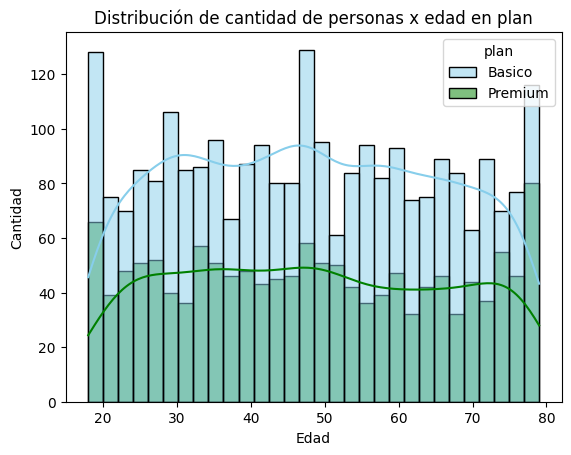

In [30]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    bins=30,
    kde=True,
    palette=['skyblue', 'green']
)

plt.xlabel("Edad")
plt.ylabel("Cantidad")
plt.title("Distribución de cantidad de personas x edad en plan")
plt.show()


💡Insights: 
La distribución de la edad es aproximadamente uniforme, lo que indica que este factor no influye de manera significativa en la elección del plan. Las barras se mantienen consistentes a lo largo del rango entre 18 y 80 años, sin concentraciones marcadas en un grupo etario específico.

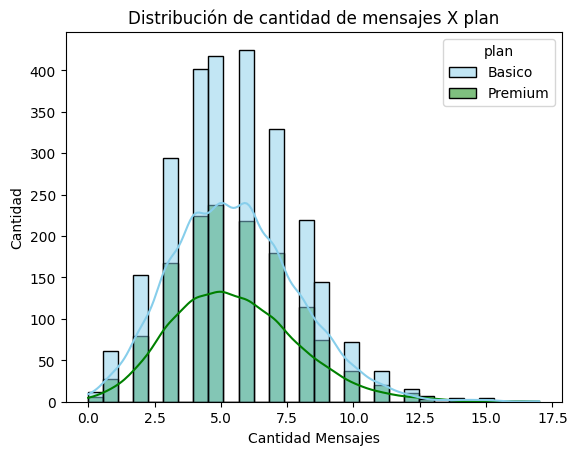

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    bins=30,
    kde=True,
    palette=['skyblue', 'green']
)

plt.xlabel("Cantidad Mensajes")
plt.ylabel("Cantidad")
plt.title("Distribución de cantidad de mensajes X plan")
plt.show()

💡Insights: 
- La distribución está sesgada hacia la derecha sesgo positivo.
Se observa que la mayor concentración de datos está entre 3 y 8 mensajes, y a medida que aumenta la cantidad de mensajes, las frecuencias disminuyen dejando una cola larga hacia valores altos (10–17 mensajes).

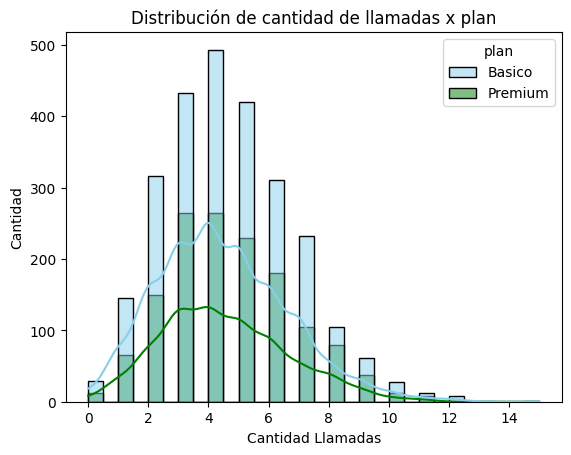

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    bins=30,
    kde=True,
    palette=['skyblue', 'green']
)

plt.xlabel("Cantidad Llamadas")
plt.ylabel("Cantidad")
plt.title("Distribución de cantidad de llamadas x plan")
plt.show()

💡Insights: 
- La distribución es asimétrica con sesgo a la derecha sesgo positivo.
Se observa que la mayor concentración de usuarios está entre 2 y 6 llamadas, y a medida que aumenta la cantidad de llamadas, las frecuencias disminuyen dejando una cola hacia valores altos (8–14 llamadas).
Esto indica que:
La mayoría de usuarios realiza pocas llamadas.
Un grupo pequeño realiza muchas llamadas, generando la cola derecha.

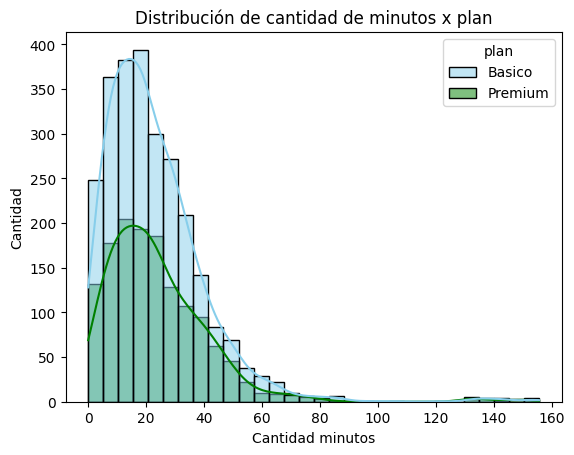

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    bins=30,
    kde=True,
    palette=['skyblue', 'green']
)

plt.xlabel("Cantidad minutos")
plt.ylabel("Cantidad")
plt.title("Distribución de cantidad de minutos x plan")
plt.show()

💡Insights: 
- Se evidencia una distribución con fuerte sesgo a la derecha sesgo positivo.
La mayor concentración de usuarios está entre 5 y 30 minutos, y a medida que aumentan los minutos, las frecuencias caen dejando una cola larga hacia valores altos.
Esto indica que:
La mayoría de usuarios consume pocos minutos.
Un grupo muy reducido consume muchos minutos, generando outliers y la cola derecha marcada.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

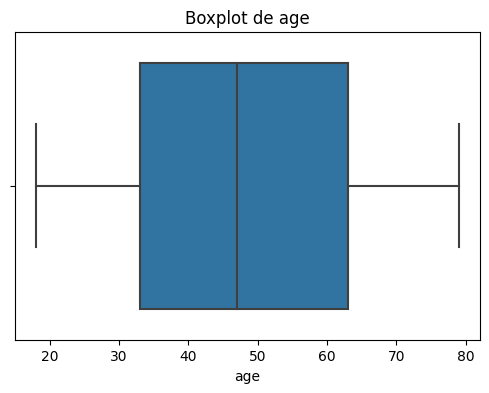

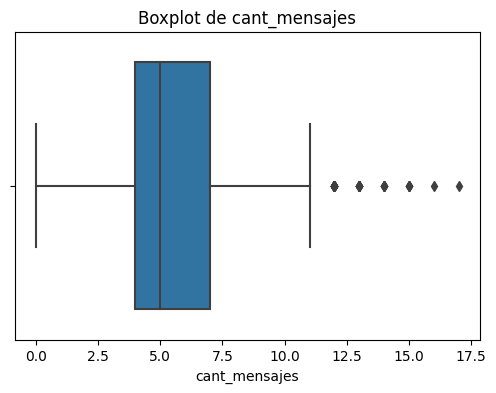

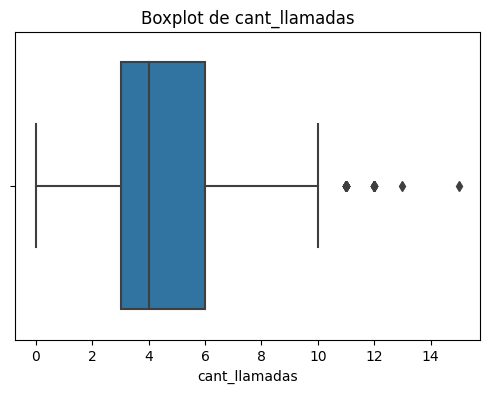

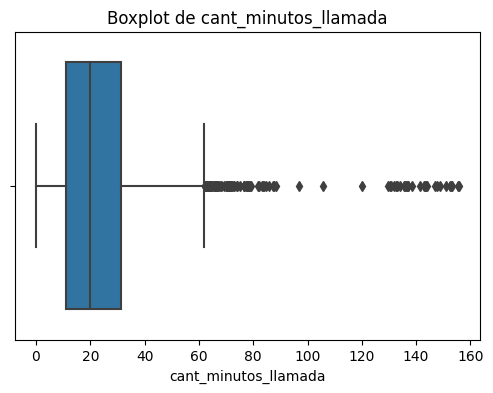

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


for col in columnas_numericas:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=user_profile, x=col)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: no presenta outliners
- cant_mensajes: si presenta outliners
- cant_llamadas: si presenta outliners
- cant_minutos_llamada: si presenta outliners

In [35]:
# Calcular límites con el método IQR
columnas_limites = ["cant_mensajes","cant_llamadas","cant_minutos_llamada"]

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3-Q1

    limite_inferior = Q1 - 1.5 * IQR  
    limite_superior = Q3 + 1.5 * IQR 
    print(col)
    print(Q1)
    print(Q3)
    print(limite_inferior)
    print(limite_superior)

    user_profile[f"outliners_{col}"] = (
        (user_profile[col] < limite_inferior) |
        (user_profile[col] > limite_superior)
    )
    


cant_mensajes
4.0
7.0
-0.5
11.5
cant_llamadas
3.0
6.0
-1.5
10.5
cant_minutos_llamada
11.12
31.415
-19.322500000000005
61.8575


In [36]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile["cant_mensajes"].describe()

count    3999.000000
mean        5.524381
std         2.358416
min         0.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        17.000000
Name: cant_mensajes, dtype: float64

In [37]:
user_profile["cant_llamadas"].describe()

count    3999.000000
mean        4.478120
std         2.144238
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        15.000000
Name: cant_llamadas, dtype: float64

In [38]:
user_profile["cant_minutos_llamada"].describe()

count    3999.000000
mean       23.317054
std        18.168095
min         0.000000
25%        11.120000
50%        19.780000
75%        31.415000
max       155.690000
Name: cant_minutos_llamada, dtype: float64

In [39]:
user_profile

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_llamadas,cant_mensajes,cant_minutos_llamada,outliners_cant_mensajes,outliners_cant_llamadas,outliners_cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,False,False,False
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,False,False,False
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,False,False,False
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,False,False,False
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,13995,Ana,Lopez,60.0,Medellín,2024-12-29 21:42:48.342085520,Basico,NaN,3.0,6.0,21.24,False,False,False
3996,13996,Carlos,Ramirez,24.0,Medellín,2024-12-30 04:17:06.256564144,Premium,NaN,3.0,4.0,2.81,False,False,False
3997,13997,Ana,Lopez,58.0,Bogotá,2024-12-30 10:51:24.171042768,Premium,NaN,3.0,5.0,11.34,False,False,False
3998,13998,Mariana,Lopez,57.0,Bogotá,2024-12-30 17:25:42.085521392,Basico,NaN,6.0,6.0,22.95,False,False,False


In [40]:
user_profile[["outliners_cant_mensajes", "outliners_cant_llamadas", "outliners_cant_minutos_llamada"]].sum()

outliners_cant_mensajes            46
outliners_cant_llamadas            30
outliners_cant_minutos_llamada    109
dtype: int64

💡 Insights sobre outliers (método IQR):

cant_mensajes: Se decide mantener los outliers, ya que representan menos del 5% del total de datos. En concreto, 46 registros se encuentran fuera del rango sobre un total de 3999 observaciones.

cant_llamadas: También se conservan los outliers, debido a que solo 30 registros están fuera de los límites establecidos, lo que equivale a menos del 5% del dataset.

cant_minutos_llamada: Aunque presenta un mayor número de valores atípicos 109 registros, estos siguen siendo inferiores al 5% del total, por lo que se opta por mantenerlos al no afectar significativamente la distribución general.

En conclusión, los valores atípicos en estas variables no representan una proporción crítica que justifique su eliminación y, por el contrario, pueden aportar información valiosa sobre comportamientos de uso intensivo

## 🧩 Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes por Uso

🎯 **Objetivo:**  
Clasificar a cada usuario en un grupo de uso (**Bajo uso, Uso medio, Alto uso**) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**

- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (`<`, `>`) para evaluar las condiciones de llamadas y mensajes y asigna:

  - `'Bajo uso'` cuando **llamadas < 5** y **mensajes < 5**
  - `'Uso medio'` cuando **llamadas < 10** y **mensajes < 10**
  - `'Alto uso'` para el resto de los casos

In [41]:
# Crear columna grupo_uso
import numpy as np
condiciones = [
    (user_profile["cant_llamadas"] < 5) & (user_profile["cant_mensajes"] < 5),
    (user_profile["cant_llamadas"] < 10) & (user_profile["cant_mensajes"] < 10),
]

valores = ["Bajo uso", "Uso medio"]

user_profile["grupo_uso"] = np.select(condiciones, valores, default="Alto uso")

In [42]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_llamadas,cant_mensajes,cant_minutos_llamada,outliners_cant_mensajes,outliners_cant_llamadas,outliners_cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,False,False,False,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,False,False,False,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,False,False,False,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,False,False,False,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,False,False,False,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [43]:
# Crear columna grupo_edad
condiciones = [
    (user_profile["age"] < 30),
    (user_profile["age"] < 60),
]

valores = ["Joven", "Adulto"]

user_profile["grupo_edad"] = np.select(condiciones, valores, default="Adulto Mayor")

In [44]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_llamadas,cant_mensajes,cant_minutos_llamada,outliners_cant_mensajes,outliners_cant_llamadas,outliners_cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,False,False,False,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,False,False,False,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,False,False,False,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,False,False,False,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,False,False,False,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

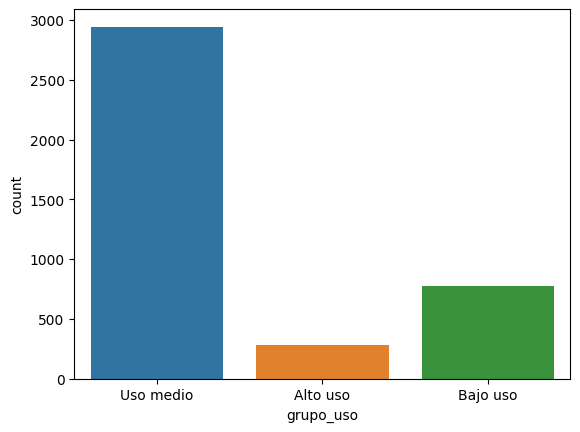

In [45]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x="grupo_uso")
plt.show()


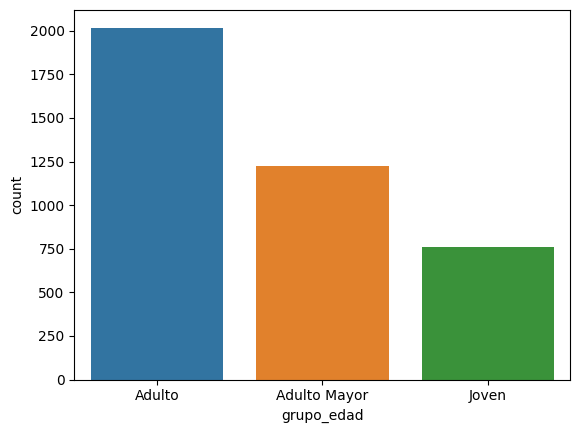

In [46]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x="grupo_edad")
plt.show()


---
## 🧩 Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en calidad de datos, segmentación, patrones de uso y oportunidades comerciales.

---

### ❓ ¿Qué problemas presentaban originalmente los datos?

**RTA:**

Durante la etapa de exploración y limpieza se identificaron los siguientes hallazgos relevantes:

- En la tabla **users**, la columna `city` presentaba **469 valores nulos** (≈ **11%** del total). Dado que esta variable no era determinante para el análisis, se recomienda imputarla con la categoría **"Sin ubicación"**.

- En la tabla **usage**, la columna `duration` tenía **22.076 valores nulos** y la columna `length` **17.896 valores nulos**. Sin embargo, estos nulos **no representaban un error**, ya que dependen directamente del tipo de registro en la columna `type` (llamada o mensaje).

- En la columna `age` de la tabla **users**, se encontraron valores fuera de rango (ej. -999). Estos fueron **imputados con la mediana**, debido a la alta dispersión de la variable.

- En la columna `reg_date` de **users**, se encontraron fechas posteriores al año 2024. Estas fueron marcadas como **NA** y se ajustó el formato de la columna a tipo fecha.

- En la columna `date` de **usage**, se detectaron valores que no cumplían el formato de fecha. Estos fueron imputados con la fecha **2024-01-01**.

---

### 👥 ¿Qué segmentos de clientes se identificaron y cómo se comportan según su edad y nivel de uso?

**RTA:**

Se identificaron tres segmentos claros según el nivel de uso:

- **Uso medio (segmento predominante):** Usuarios con entre **5 y 10 llamadas y mensajes**. Presentan un consumo estable y frecuente sin llegar a ser intensivo.

- **Bajo uso:** Usuarios con menos de **5 llamadas y mensajes**. Corresponden al segundo grupo en tamaño.

- **Alto uso:** Usuarios con más de **10 llamadas o mensajes**. Es el grupo más pequeño, pero con el consumo más intensivo.

Respecto a la edad, se observa que la **población mayor de 30 años** es la que más consume servicios y adquiere planes, mientras que los usuarios más jóvenes presentan menor adopción.

---

### 💎 ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

**RTA:**

El segmento más valioso para la compañía es el de **adultos con uso medio**, ya que representan la mayor proporción de clientes con un consumo constante, lo que garantiza estabilidad en los ingresos.

---

### 📊 ¿Qué patrones de uso extremo (outliers) se encontraron y qué implican?

**RTA:**

Se detectaron los siguientes valores atípicos mediante el método IQR:

- `cant_mensajes`: **46 registros**
- `cant_llamadas`: **30 registros**
- `cant_minutos_llamada`: **109 registros**

Estos valores representan **menos del 10% del total de datos**, por lo que no afectan de forma crítica el análisis. Por el contrario, reflejan comportamientos de **uso intensivo** que pueden ser valiosos para identificar oportunidades comerciales.

---

### 🚀 ¿Qué recomendaciones se pueden plantear para mejorar la oferta de planes?

**RTA:**

- Diseñar **planes más económicos dirigidos a la población joven**, con el fin de aumentar la captación en este segmento de bajo consumo.

- Crear **bonos adicionales de minutos o mensajes a bajo costo** para los usuarios de **alto uso**, incentivando la permanencia y el consumo adicional.

- Mantener y fortalecer los planes dirigidos al segmento de **uso medio adulto**, que representa la base más sólida de clientes para la compañía.
  

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Se evidenciaron un total de 469 valores nulos en la table users para la columna city, lo cual representa un porcentaje de 11% de valores faltantes, a su vez también se evidenciaron un total de 22076 valores nulos en la columna duration de la tabla usage los cuales se evidencio que son dependientes de la columna type por lo cual no representan ninguna falla en la data, en esta misma tabla (usage) también se evidenciaron 17896 datos nulos en la columna length que también son dependientes de la columna type por lo cual no representa fallas en la data o en el análisis.

Por otro lado en la tabla de users se encontraron edades por fuera del rango normal por lo cual se procedio a imputar con la mediana.

En la columna city se encontraron valores invalidos se recomienda imputar estos valores con "Sin ubicación"

En la columna reg_date de la tabla users se encontraron fechas erróneas que correspondían a años posteriores a 2024 las cuales se marcaron como NA y se procedió a formatear la columna a tipo date, en la tabla usage también se encontraron fechas erróneas las cuales se imputaron con la fecha 2024-01-01.


🔍 **Segmentos por Edad**
- Adulto Mayor > 60
- Adulto > 30 y < 60
- Joven < 30


📊 **Segmentos por Nivel de Uso**
- Uso Alto > 10 llamadas y mensajes
- Uso medio > 5 y < 10 llamadas y mensajes
- Uso Bajo < 5 llamadas y mensajes


➡️ Esto sugiere que
- Diseñar **planes más económicos dirigidos a la población joven**, con el fin de aumentar la captación en este segmento de bajo consumo.

- Crear **bonos adicionales de minutos o mensajes a bajo costo** para los usuarios de **alto uso**, incentivando la permanencia y el consumo adicional.

- Mantener y fortalecer los planes dirigidos al segmento de **uso medio adulto**, que representa la base más sólida de clientes para la compañía.


💡 **Recomendaciones**
- Diseñar **planes más económicos dirigidos a la población joven**, con el fin de aumentar la captación en este segmento de bajo consumo.

- Crear **bonos adicionales de minutos o mensajes a bajo costo** para los usuarios de **alto uso**, incentivando la permanencia y el consumo adicional.

- Mantener y fortalecer los planes dirigidos al segmento de **uso medio adulto**, que representa la base más sólida de clientes para la compañía.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---
Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

In [ ]:
https://github.com/DevGabo/Telecomunicaciones